# 19 - Building graphs by time of day

Up to this point we have treated the complete schedule as one static graph: a segment `u -> v` exists whenever at least one scheduled trip uses it. Here we want to stop averaging the whole day together. The set of active routes changes by hour, so a station that is hard to avoid at night may have several alternatives during the morning peak.

We split the service day into five windows and build a graph for each one. We also use `calendar.txt` to mark whether each trip runs on weekdays (Sunday-Thursday), Friday, Saturday, or more than one of those day types. We do all of the counting in one streaming pass over the 816 MB `stop_times.txt` file. Separating both time and day type should show whether the network only becomes less frequent outside peak hours or whether parts of it actually disappear.

The saved graphs are also the input we will use in notebook 20 to compare centrality and robustness across the same windows.

Our question is: how much does the topology change over the day and week? We want to distinguish a smaller network, a less frequent network, and a network that has split into disconnected pieces.

## A caveat that applies to every number below

We only have the published GTFS schedule here. Our counts describe planned trips and planned segment traversals, not passenger demand, occupancy, reliability, or service that actually ran. When we write "service volume," we mean planned departures.

## Input

* `israel-public-transportation/stop_times.txt` - 816 MB, 15.7M rows, not tracked in git; downloaded on demand from Google Drive by the cell below (same file id as notebook 02).
* `israel-public-transportation/trips.txt` - maps `trip_id` to `service_id`.
* `israel-public-transportation/calendar.txt` - maps `service_id` to the weekday pattern it runs on.
* `outputs/nb/02_graph_construction/tables/nodes.csv` - station attributes (`stop_id, stop_name, lat, lon, region, metro`) used to decorate each window's graph.

## Output

We write this notebook's results under `outputs/nb/19_time_of_day_graphs/`:

* `tables/window_summary.csv` - the main per-window table: `window, start_hour, end_hour, trips, nodes, directed_edges, avg_degree, largest_component_share`.
* `tables/edges_<window>.csv` - one file per window, `from_stop, to_stop, trip_frequency`.
* `graph_<window>.pkl` - one undirected `networkx` graph, pickled, per window.
* `tables/window_summary_by_daytype.csv` - the same statistics broken out by weekday / Friday / Saturday service.
* `tables/hourly_service_volume.csv` - planned departures from stations and trip starts for each hour of the service day.
* `tables/service_calendar_summary.csv` - how many services and how many trips run on each day of the week.
* `tables/window_edge_overlap.csv` - Jaccard overlap of the edge sets for each pair of windows.
* `figures/service_volume_by_hour.png`, `figures/network_size_by_window.png`, `figures/connectivity_by_window.png`, `figures/weekday_vs_weekend_by_window.png`, `figures/window_edge_overlap.png`.
* `window_construction_summary.json` - all the key numbers plus streaming-pass statistics.

We keep every file produced here inside that stage folder.

## Required earlier step

* `02_graph_construction` supplies `tables/nodes.csv`. This notebook can download `stop_times.txt` itself if the raw file is missing.

Once that table exists, we can run the cells below in order.

## 1. Initializing the working environment

We start by making the notebook work in both our local checkout and Google Colab. `_ensure(...)` installs only missing packages, while `find_repo_root()` looks upward for the GTFS folder and clones the repository into `/content` only when needed. The cell then defines `REPO`, `DATA`, and `OUT`; every later path is based on those three values.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

## 2. Libraries, stage folders, and tunable constants

We import the packages used for streaming, graph construction, tables, and plots, then create this stage's `tables/` and `figures/` folders under `outputs/nb/19_time_of_day_graphs/`.

We keep the settings that affect runtime or interpretation together in this cell:

* `WINDOWS` stores `(name, start_hour, end_hour)`, with an exclusive end and support for wrapping past midnight. The next cell checks that the five windows cover every hour exactly once, so a bad edit cannot silently create a gap or overlap.
* `PROGRESS_EVERY` controls progress messages during the 15.7-million-row pass. We update every window and day-type counter at the same time so the file is read once rather than five times. The main memory use is the trip lookup plus the edge counters, not the raw rows.
* `WRITE_WINDOW_PICKLES` controls whether we save `graph_<window>.pkl`. Notebook 20 needs those files, so we normally leave it enabled.
* `FIG_DPI` and `TOP_N` affect only figure size and table length.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn')

import csv, json, pickle, time
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

STAGE = OUT / '19_time_of_day_graphs'    # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
# (name, start_hour, end_hour) with end_hour EXCLUSIVE; a window may wrap past midnight.
WINDOWS = [
    ('morning_peak',   6,  9),
    ('midday',         9, 15),
    ('afternoon_peak', 15, 19),
    ('evening',        19, 23),
    ('night',          23,  6),
]

PROGRESS_EVERY = 2_000_000     # rows between progress prints in the single streaming pass
WRITE_WINDOW_PICKLES = True    # write graph_<window>.pkl (notebook 20 needs these)
FIG_DPI = 150                  # figure resolution; drop to 90 for faster, smaller files
TOP_N = 15                     # rows shown in preview tables

print('pandas', pd.__version__, '| networkx', nx.__version__)
print('this stage :', STAGE)

pandas 2.3.3 | networkx 3.4.2
this stage : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\19_time_of_day_graphs


## 3. Handling Hebrew labels

Some plots include Hebrew station names, so we set a font with Hebrew glyphs and make sure labels are passed to Matplotlib in the form expected by this environment. `fix_he()` is intentionally a no-op on this build because Matplotlib already handles the bidirectional ordering; pre-processing the same string again would reverse it. We also undo a stale text patch if an earlier cell run left one installed.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Loading the station table

We load `nodes.csv` from stage 02 because it contains the names, coordinates, regions, and metros that we need to attach to each time-window graph. The helper finds the stage by its numeric prefix and raises a direct error if the required table is missing. We print a small preview here to check that station IDs stayed as strings and the expected attributes are present.

In [4]:
# --- Stage resolution helpers ---------------------------------------------
def stage_dir(prefix, notebook_hint):
    """Return the output folder whose name starts with `prefix` (e.g. '02')."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            'No stage folder starting with ' + repr(prefix) + ' under ' + str(OUT) +
            ' - run notebook ' + notebook_hint + ' first.'
        )
    return matches[0]


def load_stage_table(prefix, filename, notebook_hint, **read_kwargs):
    """Load a CSV from an earlier stage, searching the stage folder recursively."""
    folder = stage_dir(prefix, notebook_hint)
    direct = folder / filename
    if direct.exists():
        path = direct
    else:
        found = sorted(folder.rglob(filename))
        if not found:
            raise FileNotFoundError(
                filename + ' not found anywhere under ' + str(folder) +
                ' - run notebook ' + notebook_hint + ' first; it writes ' + filename + '.'
            )
        path = found[0]
    df = pd.read_csv(path, encoding='utf-8-sig', **read_kwargs)
    print('loaded ' + filename + ': ' + format(len(df), ',') + ' rows  <-  ' + str(path))
    return df


def require_raw(filename):
    """Return the path of a raw GTFS file, or raise a clear error."""
    path = DATA / filename
    if not path.exists():
        raise FileNotFoundError(
            str(path) + ' is missing - the raw GTFS feed must be present in ' + str(DATA) + '.'
        )
    return path


nodes_df = load_stage_table('02', 'nodes.csv', '02_graph_construction',
                            dtype={'stop_id': str})
nodes_df.head(3)

loaded nodes.csv: 30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv


,stop_id,stop_name,lat,lon,region,metro,stop_use_count
0,38725,ת. רכבת יבנה מערב,31.890700,34.731191,Center,Tel Aviv,1370
1,15582,שד. הסנהדרין/שד. ירושלים,31.887865,34.734514,Center,Tel Aviv,228
2,15746,שד. ירושלים/שד. הסנהדרין,31.887569,34.733548,Center,Tel Aviv,742


## 5. Downloading `stop_times.txt`

`stop_times.txt` is too large to keep in the repository, so we check for it locally and download it only when it is missing. The smaller `trips.txt` and `calendar.txt` files are already part of the data folder. This keeps repeated runs from downloading the 816 MB file again.

In [5]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt:

 778.3 MB


## 6. Time windows and decoding GTFS times

This cell handles two details that would otherwise make the streaming pass unreliable.

First, we expand `WINDOWS` into a 24-entry hour lookup and assert that each hour appears once. That gives every valid departure a window and catches gaps or overlaps immediately.

Second, we parse GTFS times without `datetime`. GTFS allows hours above 24, so `25:30:00` means 01:30 on the following clock day while still belonging to the same service day. `gtfs_seconds` splits the string directly, and we use the hour modulo 24 only when assigning a time window. The assertions check normal, midnight-crossing, and invalid values before we process millions of rows.

In [6]:
# --- Expand WINDOWS into an hour -> window lookup --------------------------
def window_hours(start, end):
    """Hours covered by [start, end); wraps past midnight when end <= start."""
    span = (end - start) % 24 or 24
    return [(start + i) % 24 for i in range(span)]


WINDOW_NAMES = [name for name, _, _ in WINDOWS]
WINDOW_INDEX = {name: i for i, name in enumerate(WINDOW_NAMES)}

_hour_owner = {}
for _name, _s, _e in WINDOWS:
    for _h in window_hours(_s, _e):
        if _h in _hour_owner:
            raise ValueError(
                'WINDOWS overlap: hour ' + str(_h) + ' is claimed by both ' +
                _hour_owner[_h] + ' and ' + _name + '.'
            )
        _hour_owner[_h] = _name
_gaps = [h for h in range(24) if h not in _hour_owner]
if _gaps:
    raise ValueError('WINDOWS leave hours uncovered: ' + str(_gaps))

# Plain python list -> fastest possible lookup inside the 15.7M-row loop.
HOUR_TO_WIDX = [WINDOW_INDEX[_hour_owner[h]] for h in range(24)]
HOUR_TO_WINDOW = {h: _hour_owner[h] for h in range(24)}


def gtfs_seconds(value):
    """Parse an HH:MM:SS GTFS time into seconds since SERVICE midnight.

    Hours may be >= 24 (25:30:00 = 01:30 on the next calendar day, same service day).
    Never use datetime/strptime here - it raises on hours >= 24.
    Returns None for blank or malformed values.
    """
    if not value:
        return None
    parts = value.split(':')
    if len(parts) != 3:
        return None
    try:
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
    except ValueError:
        return None


# Sanity checks on the two tricky cases.
assert gtfs_seconds('05:10:00') == 5 * 3600 + 10 * 60
assert gtfs_seconds('25:30:00') == 25 * 3600 + 30 * 60
assert (gtfs_seconds('25:30:00') // 3600) % 24 == 1
assert gtfs_seconds('') is None and gtfs_seconds('nonsense') is None

print('hour -> window map:')
for name, s, e in WINDOWS:
    hrs = window_hours(s, e)
    print('  ' + name.ljust(16) + str(s).rjust(2) + ':00 -> ' + str(e).rjust(2) +
          ':00  (' + str(len(hrs)) + ' hours: ' + ', '.join(str(h) for h in hrs) + ')')

hour -> window map:
  morning_peak     6:00 ->  9:00  (3 hours: 6, 7, 8)
  midday           9:00 -> 15:00  (6 hours: 9, 10, 11, 12, 13, 14)
  afternoon_peak  15:00 -> 19:00  (4 hours: 15, 16, 17, 18)
  evening         19:00 -> 23:00  (4 hours: 19, 20, 21, 22)
  night           23:00 ->  6:00  (7 hours: 23, 0, 1, 2, 3, 4, 5)


## 7. `calendar.txt` - which day of the week does each service run on?

We use `calendar.txt` to connect each `service_id` to the days when it normally runs. Because the weekly pattern in Israel is not well represented by a Monday-Friday/weekend split, we group Sunday-Thursday as weekdays and keep Friday and Saturday separate.

We reduce the seven flags to three independent booleans:

* `runs_weekday` - runs on at least one of Sunday through Thursday;
* `runs_friday`;
* `runs_saturday`.

The flags are allowed to overlap. For example, a service running Sunday through Friday belongs in both the weekday and Friday views. The day-type columns therefore do not add up to an all-service total, and we print the pattern counts so we can verify how the feed is being classified.

Some services have all seven flags set to zero. They would normally be resolved with `calendar_dates.txt`, but that file is not available here. We keep those services in the all-service graphs, mark their day type as unknown, and exclude them from the weekday/Friday/Saturday breakdown instead of guessing.

In [7]:
# --- Read calendar.txt and reduce every service to day-type flags ----------
DAY_COLS = ['sunday', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']
WEEKDAY_COLS = ['sunday', 'monday', 'tuesday', 'wednesday', 'thursday']

# Bit codes, so the streaming pass can carry the day-type in a single small int.
BIT_WEEKDAY, BIT_FRIDAY, BIT_SATURDAY = 1, 2, 4

calendar_path = require_raw('calendar.txt')
service_code = {}          # service_id -> bit code
day_service_counts = Counter()
pattern_counts = Counter()

with open(calendar_path, encoding='utf-8-sig', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        flags = {d: str(row.get(d, '0')).strip() == '1' for d in DAY_COLS}
        code = 0
        if any(flags[d] for d in WEEKDAY_COLS):
            code |= BIT_WEEKDAY
        if flags['friday']:
            code |= BIT_FRIDAY
        if flags['saturday']:
            code |= BIT_SATURDAY
        service_code[str(row['service_id']).strip()] = code
        for d in DAY_COLS:
            if flags[d]:
                day_service_counts[d] += 1
        pattern_counts[''.join('1' if flags[d] else '0' for d in DAY_COLS)] += 1

n_services = len(service_code)
n_unknown_services = sum(1 for c in service_code.values() if c == 0)
print('services in calendar.txt      : ' + format(n_services, ','))
print('services with no day flag set : ' + format(n_unknown_services, ',') +
      '  (no calendar_dates.txt in this feed -> day of week unknown)')
print()
print('Most common weekly patterns (Sun Mon Tue Wed Thu Fri Sat):')
for pat, cnt in pattern_counts.most_common(10):
    print('  ' + ' '.join(pat) + '   ' + format(cnt, '>8,') + ' services')

services in calendar.txt      : 44,770
services with no day flag set : 232  (no calendar_dates.txt in this feed -> day of week unknown)

Most common weekly patterns (Sun Mon Tue Wed Thu Fri Sat):
  1 1 1 1 1 0 0     11,858 services
  0 0 0 0 0 1 0      8,056 services
  1 1 1 1 1 1 0      5,167 services
  0 0 0 0 0 0 1      5,048 services
  0 0 0 1 0 0 0      2,902 services
  0 0 1 0 0 0 0      2,201 services
  1 1 1 1 1 0 1      1,846 services
  1 0 0 0 0 0 0      1,719 services
  0 0 0 0 1 0 0      1,080 services
  1 1 0 0 0 0 0      1,046 services


## 8. `trips.txt` - attaching a day-type to each trip

`stop_times.txt` contains `trip_id` but not `service_id`, so we join `trips.txt` to the calendar classification and build a compact `trip_id -> day-type bit code` lookup before streaming the large file. This lets each row be classified with one dictionary lookup.

We also count trips by day type. This is more useful than counting service IDs because one service ID can contain many more scheduled journeys than another. The printed table gives us an early check on how different weekday, Friday, and Saturday supply actually is.

In [8]:
# --- Map every trip_id to its day-type bit code ----------------------------
trips_path = require_raw('trips.txt')
trip_code = {}
trips_missing_service = 0

with open(trips_path, encoding='utf-8-sig', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        sid = str(row.get('service_id', '')).strip()
        if sid not in service_code:
            trips_missing_service += 1
        trip_code[str(row['trip_id']).strip()] = service_code.get(sid, 0)

n_trips_total = len(trip_code)
trip_day_counts = {
    'weekday_sun_thu': sum(1 for c in trip_code.values() if c & BIT_WEEKDAY),
    'friday': sum(1 for c in trip_code.values() if c & BIT_FRIDAY),
    'saturday': sum(1 for c in trip_code.values() if c & BIT_SATURDAY),
    'unknown': sum(1 for c in trip_code.values() if c == 0),
}

print('trips in trips.txt                 : ' + format(n_trips_total, ','))
print('trips whose service_id is missing  : ' + format(trips_missing_service, ','))
print()
print('Scheduled trips by day of week (a trip can count in more than one row):')
for label, cnt in trip_day_counts.items():
    share = 100.0 * cnt / n_trips_total if n_trips_total else 0.0
    print('  ' + label.ljust(18) + format(cnt, '>9,') + '   ' + format(share, '5.1f') + '% of all trips')

service_calendar = pd.DataFrame(
    [{'day': d, 'services_running': day_service_counts.get(d, 0)} for d in DAY_COLS]
)
service_calendar['is_israeli_weekend'] = service_calendar['day'].isin(['friday', 'saturday'])
service_calendar.to_csv(TABLES / 'service_calendar_summary.csv', index=False, encoding='utf-8-sig')
service_calendar

trips in trips.txt                 : 420,133
trips whose service_id is missing  : 0

Scheduled trips by day of week (a trip can count in more than one row):
  weekday_sun_thu     337,073    80.2% of all trips
  friday              113,924    27.1% of all trips
  saturday             33,135     7.9% of all trips
  unknown                   0     0.0% of all trips


,day,services_running,is_israeli_weekend
0,sunday,23186,False
1,monday,22816,False
2,tuesday,23783,False
3,wednesday,23902,False
4,thursday,22177,False
5,friday,14862,True
6,saturday,7540,True


## 9. The single streaming pass over `stop_times.txt`

This is the expensive part, so we read `stop_times.txt` once and update every counter during the same pass.

The file is ordered by `(trip_id, stop_sequence)`, so adjacent rows with the same trip ID form one directed segment. We assign that segment to the window containing the departure time at its origin stop, then update these structures:

* `edges_all[w]` - segment-traversal counts per window, across all services;
* `edges_wd[w]`, `edges_fr[w]`, `edges_sa[w]` - the same, restricted to trips whose service runs on weekdays / Friday / Saturday;
* `hour_*` - planned departures from stations per hour of the service day, and per hour and day-type;
* `trip_start_*` - trip starts per hour (the first row in each trip block);
* `trip_window_mask` - a 5-bit mask per trip recording which windows that trip touched, so a trip crossing the 09:00 boundary is counted in both windows it serves.

We never keep the raw rows. Memory grows with the unique edges across the windows plus the trip lookup, rather than with all 15.7 million stop-time records.

The progress messages let us see that the pass is moving and how long it takes. Building all counters together avoids repeating the same large read for every window.

We count rows with empty or invalid departure times and skip them. That keeps the final summary explicit about how much data could not be assigned.

In [9]:
def stream_window_edges(path, trip_code, progress_every=PROGRESS_EVERY):
    """One pass over stop_times.txt, building every per-window counter at once.

    A segment (prev_stop -> stop) is assigned to the window containing the
    DEPARTURE time at prev_stop. Times are seconds since service midnight and the
    hour is taken modulo 24, so a 25:30 departure lands in the window covering 01:00.
    """
    n_w = len(WINDOW_NAMES)
    edges_all = [defaultdict(int) for _ in range(n_w)]
    edges_wd = [defaultdict(int) for _ in range(n_w)]
    edges_fr = [defaultdict(int) for _ in range(n_w)]
    edges_sa = [defaultdict(int) for _ in range(n_w)]

    hour_all = [0] * 24
    hour_wd = [0] * 24
    hour_fr = [0] * 24
    hour_sa = [0] * 24
    start_all = [0] * 24
    start_wd = [0] * 24
    start_fr = [0] * 24
    start_sa = [0] * 24

    trip_window_mask = defaultdict(int)

    rows_read = 0
    segments = 0
    self_loops_skipped = 0
    bad_times = 0
    rows_past_midnight = 0
    trips_seen = 0
    trips_not_in_trips_txt = set()
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index('trip_id')
        si = header.index('stop_id')
        di = header.index('departure_time')

        prev_trip = None
        prev_stop = None
        prev_secs = None
        code = 0

        for row in reader:
            rows_read += 1
            trip = row[ti]
            stop = row[si]
            secs = gtfs_seconds(row[di])
            if secs is None:
                bad_times += 1
            elif secs >= 86400:
                rows_past_midnight += 1

            new_trip = trip != prev_trip
            if new_trip:
                trips_seen += 1
                if trip in trip_code:
                    code = trip_code[trip]
                else:
                    code = 0
                    if len(trips_not_in_trips_txt) < 50:
                        trips_not_in_trips_txt.add(trip)

            is_wd = bool(code & BIT_WEEKDAY)
            is_fr = bool(code & BIT_FRIDAY)
            is_sa = bool(code & BIT_SATURDAY)

            if secs is not None:
                h = (secs // 3600) % 24
                hour_all[h] += 1
                if is_wd:
                    hour_wd[h] += 1
                if is_fr:
                    hour_fr[h] += 1
                if is_sa:
                    hour_sa[h] += 1
                if new_trip:
                    start_all[h] += 1
                    if is_wd:
                        start_wd[h] += 1
                    if is_fr:
                        start_fr[h] += 1
                    if is_sa:
                        start_sa[h] += 1

            if not new_trip and prev_stop is not None and prev_secs is not None:
                if prev_stop != stop:
                    w = HOUR_TO_WIDX[(prev_secs // 3600) % 24]
                    key = (prev_stop, stop)
                    edges_all[w][key] += 1
                    if is_wd:
                        edges_wd[w][key] += 1
                    if is_fr:
                        edges_fr[w][key] += 1
                    if is_sa:
                        edges_sa[w][key] += 1
                    trip_window_mask[trip] |= (1 << w)
                    segments += 1
                else:
                    self_loops_skipped += 1

            prev_trip, prev_stop, prev_secs = trip, stop, secs

            if progress_every and rows_read % progress_every == 0:
                uniq = sum(len(d) for d in edges_all)
                print('    ' + format(rows_read, ',') + ' rows | ' + format(uniq, ',') +
                      ' window-segments | ' + format(time.time() - t0, ',.0f') + 's')

    stats = {
        'stop_times_rows': rows_read,
        'trip_blocks': trips_seen,
        'segments_assigned': segments,
        'self_loops_skipped': self_loops_skipped,
        'rows_with_unparseable_time': bad_times,
        'rows_with_hour_ge_24': rows_past_midnight,
        'trips_absent_from_trips_txt_sample': sorted(trips_not_in_trips_txt)[:5],
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    hourly = {'all': hour_all, 'weekday': hour_wd, 'friday': hour_fr, 'saturday': hour_sa}
    starts = {'all': start_all, 'weekday': start_wd, 'friday': start_fr, 'saturday': start_sa}
    edges = {'all': edges_all, 'weekday': edges_wd, 'friday': edges_fr, 'saturday': edges_sa}
    return edges, hourly, starts, trip_window_mask, stats


print('Streaming ' + STOP_TIMES.name + ' (~15.7M rows, one pass, expect 4-8 minutes) ...')
edge_sets, hourly_counts, start_counts, trip_window_mask, stream_stats = stream_window_edges(
    STOP_TIMES, trip_code)

print()
print('Streaming statistics:')
for k, v in stream_stats.items():
    print('  ' + k + ': ' + str(v))

Streaming stop_times.txt (~15.7M rows, one pass, expect 4-8 minutes) ...


    2,000,000 rows | 93,762 window-segments | 3s


    4,000,000 rows | 137,368 window-segments | 6s


    6,000,000 rows | 159,635 window-segments | 10s


    8,000,000 rows | 177,293 window-segments | 14s


    10,000,000 rows | 193,449 window-segments | 17s


    12,000,000 rows | 206,174 window-segments | 21s


    14,000,000 rows | 220,831 window-segments | 25s



Streaming statistics:
  stop_times_rows: 15711624
  trip_blocks: 420133
  segments_assigned: 15290773
  self_loops_skipped: 718
  rows_with_unparseable_time: 0
  rows_with_hour_ge_24: 152485
  trips_absent_from_trips_txt_sample: []
  elapsed_seconds: 28.1


## 10. Service volume by hour of the service day

We first plot the schedule itself before interpreting any graph statistic. For each clock hour we count planned station departures and trip starts, both overall and by day type. Because a service can belong to more than one day type, these columns describe the available schedule for each type of day and should not be summed.

We shade the five windows behind the hourly curves so we can check whether the chosen boundaries match changes in scheduled service. Comparing weekday, Friday, and Saturday on the same axes also shows whether the weekly split is large enough to affect the later topology results.

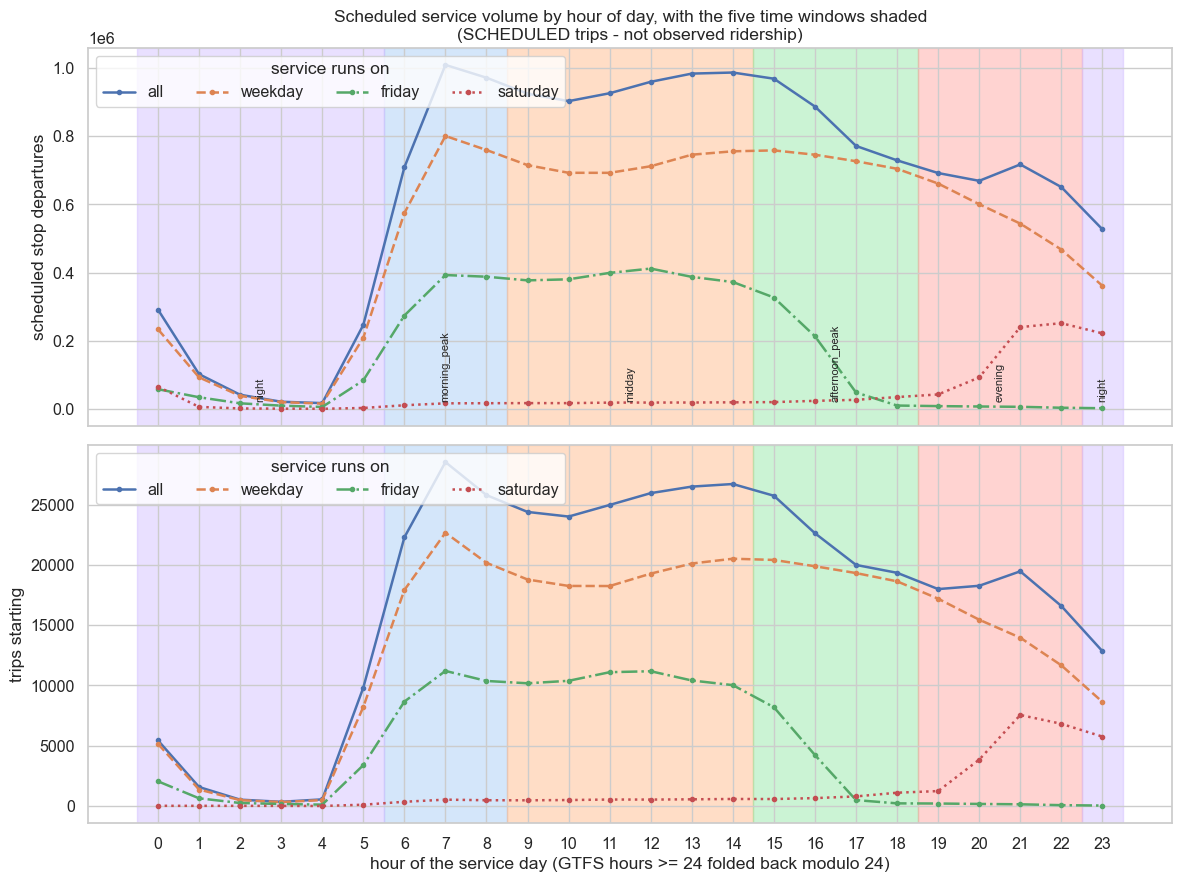

,hour,window,stop_departures_all,stop_departures_weekday,stop_departures_friday,stop_departures_saturday,trips_starting_all,trips_starting_weekday,trips_starting_friday,trips_starting_saturday
0,0,night,291564,233902,58162,65643,5443,5157,2051,21
1,1,night,102256,92867,34585,6286,1578,1371,642,19
2,2,night,41917,38631,16792,1716,531,489,254,19
3,3,night,21426,20360,9945,1181,353,331,170,15
4,4,night,17454,15974,6065,733,555,491,119,7
5,5,night,246729,208976,84111,3145,9819,8214,3391,111
6,6,morning_peak,709004,574718,274239,11114,22276,17910,8659,356
7,7,morning_peak,1009421,800967,393040,16757,28517,22660,11204,532
8,8,morning_peak,971836,759779,388134,17099,25778,20165,10372,483
9,9,midday,925041,715371,377442,17422,24384,18782,10178,478


In [10]:
# --- Hourly service volume table ------------------------------------------
hourly_df = pd.DataFrame({
    'hour': list(range(24)),
    'window': [HOUR_TO_WINDOW[h] for h in range(24)],
    'stop_departures_all': hourly_counts['all'],
    'stop_departures_weekday': hourly_counts['weekday'],
    'stop_departures_friday': hourly_counts['friday'],
    'stop_departures_saturday': hourly_counts['saturday'],
    'trips_starting_all': start_counts['all'],
    'trips_starting_weekday': start_counts['weekday'],
    'trips_starting_friday': start_counts['friday'],
    'trips_starting_saturday': start_counts['saturday'],
})
hourly_df.to_csv(TABLES / 'hourly_service_volume.csv', index=False, encoding='utf-8-sig')


def contiguous_runs(hours):
    """Collapse a list of hours into (first, last) runs, for shading a wrapped window."""
    hs = sorted(hours)
    runs, start, prev = [], hs[0], hs[0]
    for h in hs[1:]:
        if h == prev + 1:
            prev = h
        else:
            runs.append((start, prev))
            start = prev = h
    runs.append((start, prev))
    return runs


band_palette = sns.color_palette('pastel', len(WINDOWS))
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for ax, (col_prefix, ylabel) in zip(
        axes,
        [('stop_departures', 'scheduled stop departures'),
         ('trips_starting', 'trips starting')]):
    for i, (name, s, e) in enumerate(WINDOWS):
        for a, b in contiguous_runs(window_hours(s, e)):
            ax.axvspan(a - 0.5, b + 0.5, color=band_palette[i], alpha=0.45, zorder=0)
    for suffix, style in [('all', '-'), ('weekday', '--'), ('friday', '-.'), ('saturday', ':')]:
        ax.plot(hourly_df['hour'], hourly_df[col_prefix + '_' + suffix],
                style, marker='o', markersize=3, linewidth=1.8, label=suffix, zorder=3)
    ax.set_ylabel(ylabel)
    ax.legend(title='service runs on', ncol=4, loc='upper left')

for i, (name, s, e) in enumerate(WINDOWS):
    for a, b in contiguous_runs(window_hours(s, e)):
        axes[0].text((a + b) / 2.0, axes[0].get_ylim()[1] * 0.02, name,
                     ha='center', va='bottom', fontsize=8, rotation=90, zorder=4)

axes[1].set_xlabel('hour of the service day (GTFS hours >= 24 folded back modulo 24)')
axes[1].set_xticks(range(24))
axes[0].set_title('Scheduled service volume by hour of day, with the five time windows shaded\n'
                  '(SCHEDULED trips - not observed ridership)')
plt.tight_layout()
plt.savefig(FIGURES / 'service_volume_by_hour.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

hourly_df

## 11. Building one graph per window

We now convert each window's directed segment counts into the same kind of undirected graph used in the static analysis. Opposite directions become one edge and their traversal counts are added. We then attach names, coordinates, regions, and metros from `nodes.csv` so each saved graph contains the station information needed later.

For each window we record:

* `trips` - trips contributing at least one segment. A trip crossing a boundary appears in each window it touches, so the window values are not meant to sum to a unique-trip total.
* `nodes` - stations with at least one active segment during the window.
* `directed_edges` - unique ordered segments, matching the convention used in stage 02.
* `avg_degree` - average undirected degree, `2m/n`.
* `largest_component_share` - the fraction of active nodes in the largest connected component. A lower value means the scheduled network is already split before we remove anything.

We save both an edge table and a graph pickle for every window. These are the direct inputs for the time-dependent centrality and attack tests in notebook 20.

In [11]:
# --- Node attributes from stage 02 ----------------------------------------
def _num(value):
    """Coerce to float; return None for blanks, NaN or non-numeric input."""
    if value is None:
        return None
    try:
        f = float(value)
    except (TypeError, ValueError):
        return None
    return None if not np.isfinite(f) else f


def _txt(value):
    """Coerce to a plain string; NaN and None become an empty string."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ''
    return str(value)


NODE_ATTR = {}
for rec in nodes_df.to_dict('records'):
    NODE_ATTR[str(rec.get('stop_id'))] = {
        'stop_name': _txt(rec.get('stop_name')),
        'lat': _num(rec.get('lat')),
        'lon': _num(rec.get('lon')),
        'region': _txt(rec.get('region')),
        'metro': _txt(rec.get('metro')),
    }
_DEFAULT_ATTR = {'stop_name': '', 'lat': None, 'lon': None, 'region': '', 'metro': ''}


def build_undirected(edge_dict):
    """Undirected projection of a directed segment counter; weights of both directions summed."""
    G = nx.Graph()
    for (u, v), w in edge_dict.items():
        if G.has_edge(u, v):
            G[u][v]['weight'] += w
        else:
            G.add_edge(u, v, weight=w)
    for n in G.nodes():
        G.nodes[n].update(NODE_ATTR.get(n, _DEFAULT_ATTR))
    return G


def graph_stats(G):
    """nodes, undirected edges, avg degree, largest-component share."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    if n == 0:
        return {'nodes': 0, 'undirected_edges': 0, 'avg_degree': 0.0,
                'components': 0, 'largest_component_size': 0,
                'largest_component_share': 0.0}
    comps = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
    return {
        'nodes': n,
        'undirected_edges': m,
        'avg_degree': round(2.0 * m / n, 3),
        'components': len(comps),
        'largest_component_size': comps[0],
        'largest_component_share': round(comps[0] / n, 4),
    }


# --- Trips per window, from the 5-bit masks collected during the pass ------
trips_per_window = [0] * len(WINDOW_NAMES)
trips_per_window_by_daytype = {dt: [0] * len(WINDOW_NAMES)
                               for dt in ('weekday', 'friday', 'saturday')}
for trip, mask in trip_window_mask.items():
    code = trip_code.get(trip, 0)
    for w in range(len(WINDOW_NAMES)):
        if mask & (1 << w):
            trips_per_window[w] += 1
            if code & BIT_WEEKDAY:
                trips_per_window_by_daytype['weekday'][w] += 1
            if code & BIT_FRIDAY:
                trips_per_window_by_daytype['friday'][w] += 1
            if code & BIT_SATURDAY:
                trips_per_window_by_daytype['saturday'][w] += 1

# --- Build, save and summarise the all-service window graphs ---------------
window_graphs = {}
summary_rows = []
for w, (name, s, e) in enumerate(WINDOWS):
    ed = edge_sets['all'][w]
    G = build_undirected(ed)
    window_graphs[name] = G
    st = graph_stats(G)

    edges_out = pd.DataFrame(
        [{'from_stop': u, 'to_stop': v, 'trip_frequency': int(c)} for (u, v), c in ed.items()]
    ).sort_values('trip_frequency', ascending=False)
    edges_out.to_csv(TABLES / ('edges_' + name + '.csv'), index=False, encoding='utf-8-sig')

    if WRITE_WINDOW_PICKLES:
        with open(STAGE / ('graph_' + name + '.pkl'), 'wb') as fh:
            pickle.dump(G, fh)

    summary_rows.append({
        'window': name,
        'start_hour': s,
        'end_hour': e,
        'trips': trips_per_window[w],
        'nodes': st['nodes'],
        'directed_edges': len(ed),
        'avg_degree': st['avg_degree'],
        'largest_component_share': st['largest_component_share'],
    })
    print(name.ljust(16) + 'nodes ' + format(st['nodes'], '>6,') +
          ' | directed edges ' + format(len(ed), '>7,') +
          ' | avg degree ' + format(st['avg_degree'], '5.2f') +
          ' | LCC share ' + format(st['largest_component_share'], '5.3f') +
          ' | components ' + format(st['components'], '>5,'))

window_summary = pd.DataFrame(summary_rows)
window_summary.to_csv(TABLES / 'window_summary.csv', index=False, encoding='utf-8-sig')
window_summary

morning_peak    nodes 30,072 | directed edges  46,945 | avg degree  3.11 | LCC share 0.993 | components    10


midday          nodes 30,195 | directed edges  48,204 | avg degree  3.18 | LCC share 0.993 | components    13


afternoon_peak  nodes 30,057 | directed edges  47,172 | avg degree  3.13 | LCC share 0.993 | components    12


evening         nodes 29,359 | directed edges  44,936 | avg degree  3.05 | LCC share 0.993 | components     8
night           nodes 25,967 | directed edges  38,203 | avg degree  2.93 | LCC share 0.988 | components    23


,window,start_hour,end_hour,trips,nodes,directed_edges,avg_degree,largest_component_share
0,morning_peak,6,9,83924,30072,46945,3.110,0.9927
1,midday,9,15,168443,30195,48204,3.180,0.9925
2,afternoon_peak,15,19,104733,30057,47172,3.127,0.9925
3,evening,19,23,84471,29359,44936,3.050,0.9927
4,night,23,6,41766,25967,38203,2.932,0.9883


## 12. The same windows, broken out by day-type

Next we rebuild the five summaries separately for weekday, Friday, and Saturday service. We do not save these day-type graphs because the next notebook uses the all-service windows; we only need their statistics here to see how much of each window's topology depends on the day of the week.

The three day types can overlap, and unknown-calendar services appear only in the all-service result. We keep that distinction in mind when comparing the counts.

In [12]:
# --- Window statistics per day type ---------------------------------------
daytype_rows = []
for daytype in ('weekday', 'friday', 'saturday'):
    for w, (name, s, e) in enumerate(WINDOWS):
        ed = edge_sets[daytype][w]
        st = graph_stats(build_undirected(ed))
        daytype_rows.append({
            'window': name,
            'day_type': daytype,
            'start_hour': s,
            'end_hour': e,
            'trips': trips_per_window_by_daytype[daytype][w],
            'nodes': st['nodes'],
            'directed_edges': len(ed),
            'avg_degree': st['avg_degree'],
            'components': st['components'],
            'largest_component_share': st['largest_component_share'],
        })

daytype_summary = pd.DataFrame(daytype_rows)
daytype_summary.to_csv(TABLES / 'window_summary_by_daytype.csv', index=False, encoding='utf-8-sig')

pivot_nodes = daytype_summary.pivot(index='window', columns='day_type', values='nodes')
pivot_nodes = pivot_nodes.reindex(WINDOW_NAMES)
print('Stations reachable in each window, by day type:')
print(pivot_nodes.to_string())
print()

saturday_total = daytype_summary.loc[daytype_summary['day_type'] == 'saturday', 'directed_edges'].sum()
weekday_total = daytype_summary.loc[daytype_summary['day_type'] == 'weekday', 'directed_edges'].sum()
if weekday_total:
    print('Saturday segment coverage is ' +
          format(100.0 * saturday_total / weekday_total, '.1f') +
          '% of the weekday figure (summed over windows).')

daytype_summary

Stations reachable in each window, by day type:
day_type        friday  saturday  weekday
window                                   
morning_peak     29165      3280    30010
midday           29609      4331    30143
afternoon_peak   26132      7942    30029
evening           2119     25435    29245
night            18922     21316    24824

Saturday segment coverage is 38.0% of the weekday figure (summed over windows).


,window,day_type,start_hour,end_hour,trips,nodes,directed_edges,avg_degree,components,largest_component_share
0,morning_peak,weekday,6,9,66808,30010,46581,3.093,10,0.9927
1,midday,weekday,9,15,127436,30143,47240,3.122,13,0.9925
2,afternoon_peak,weekday,15,19,90944,30029,46554,3.089,12,0.9925
3,evening,weekday,19,23,69766,29245,43653,2.975,8,0.9927
4,night,weekday,23,6,31507,24824,35620,2.860,23,0.9843
5,morning_peak,friday,6,9,32705,29165,43121,2.947,10,0.9925
6,midday,friday,9,15,69377,29609,45366,3.053,12,0.9924
7,afternoon_peak,friday,15,19,19466,26132,36504,2.787,19,0.9893
8,evening,friday,19,23,738,2119,2372,2.238,11,0.6239
9,night,friday,23,6,6704,18922,24425,2.576,29,0.9602


## 13. How network size changes between windows

We plot three views of the summaries. Station and edge counts show network size; average degree and largest-component share show whether connectivity changes along with size; and the day-type station counts show how the weekly schedule changes each window. Together these plots help us tell simple thinning apart from actual fragmentation.

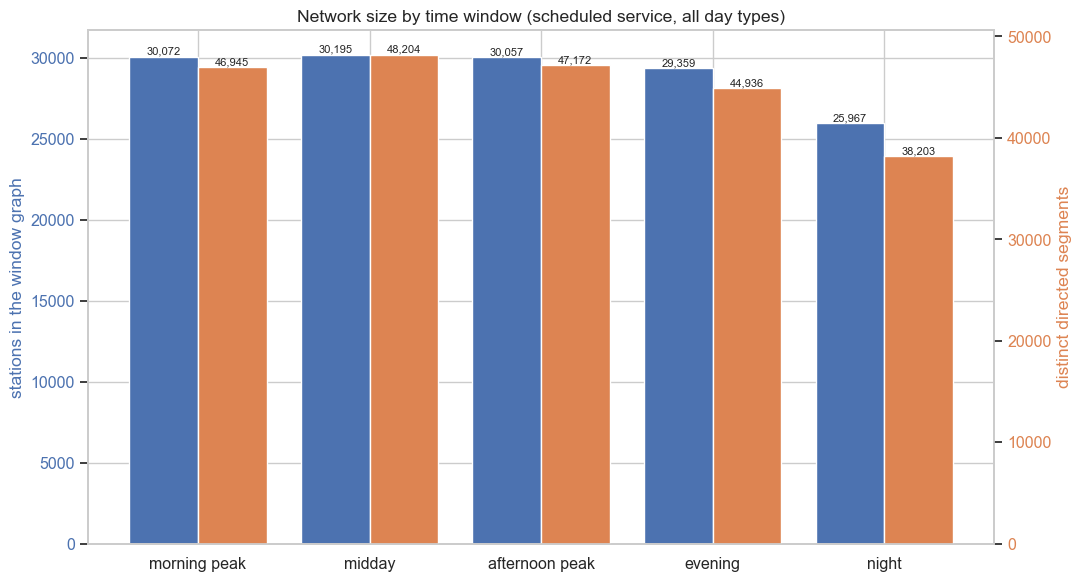

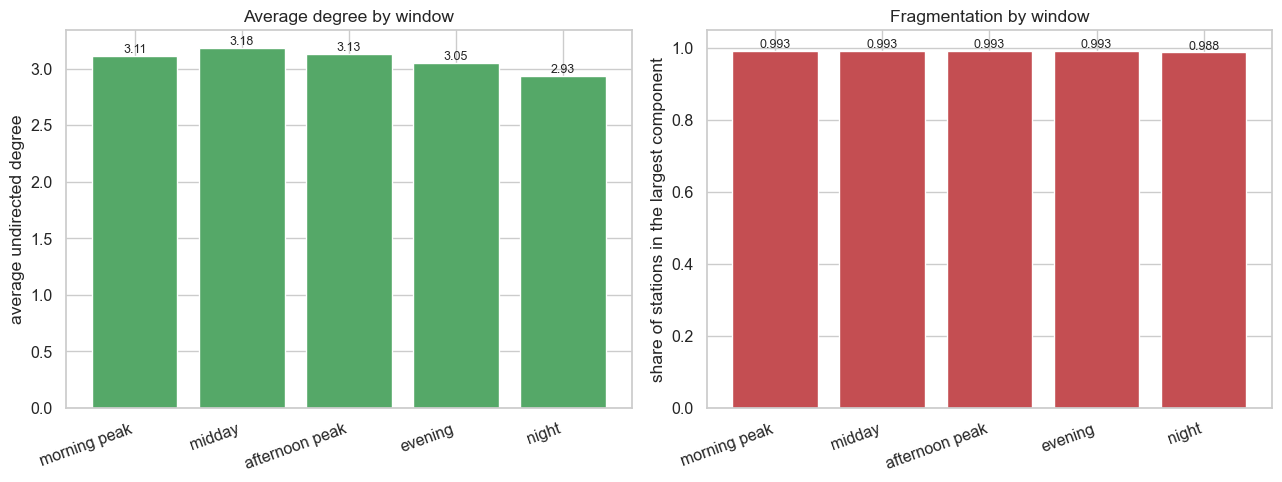

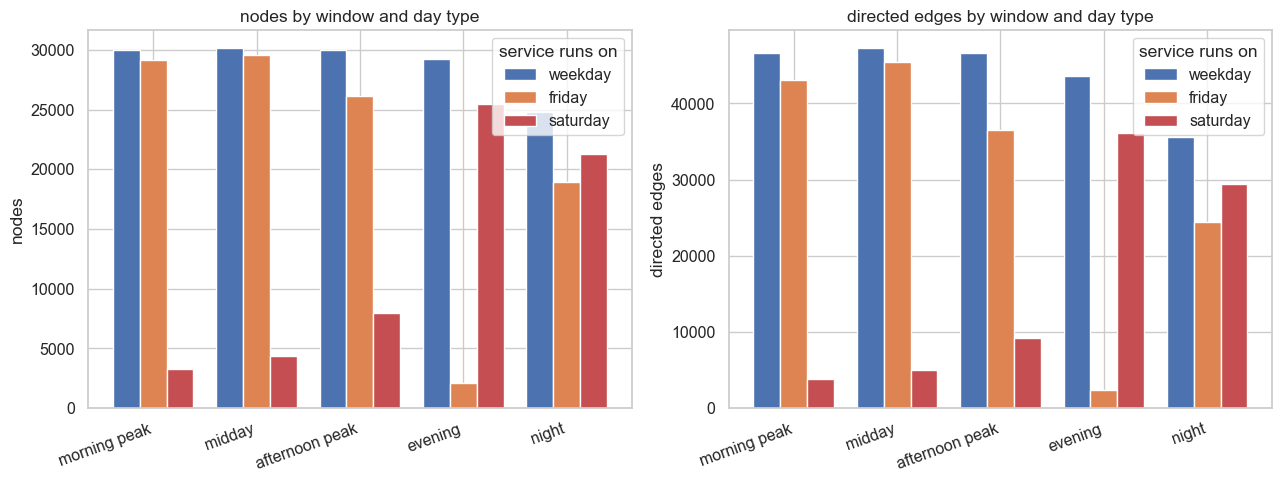

In [13]:
# --- Figure: network size across windows ----------------------------------
order = WINDOW_NAMES
ws = window_summary.set_index('window').reindex(order)
x = np.arange(len(order))

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(x - 0.2, ws['nodes'], width=0.4, label='stations (nodes)', color='#4C72B0')
ax1.set_ylabel('stations in the window graph', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax2 = ax1.twinx()
ax2.bar(x + 0.2, ws['directed_edges'], width=0.4, label='directed segments', color='#DD8452')
ax2.set_ylabel('distinct directed segments', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.grid(False)
ax1.set_xticks(x)
ax1.set_xticklabels([n.replace('_', ' ') for n in order])
ax1.set_title('Network size by time window (scheduled service, all day types)')
for i, (n, e) in enumerate(zip(ws['nodes'], ws['directed_edges'])):
    ax1.text(i - 0.2, n, format(int(n), ','), ha='center', va='bottom', fontsize=8)
    ax2.text(i + 0.2, e, format(int(e), ','), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'network_size_by_window.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

# --- Figure: connectivity across windows ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(x, ws['avg_degree'], color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace('_', ' ') for n in order], rotation=20, ha='right')
axes[0].set_ylabel('average undirected degree')
axes[0].set_title('Average degree by window')
for i, v in enumerate(ws['avg_degree']):
    axes[0].text(i, v, format(v, '.2f'), ha='center', va='bottom', fontsize=9)

axes[1].bar(x, ws['largest_component_share'], color='#C44E52')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace('_', ' ') for n in order], rotation=20, ha='right')
axes[1].set_ylabel('share of stations in the largest component')
axes[1].set_title('Fragmentation by window')
for i, v in enumerate(ws['largest_component_share']):
    axes[1].text(i, v, format(v, '.3f'), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'connectivity_by_window.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

# --- Figure: weekday vs Friday vs Saturday --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
width = 0.26
colors = {'weekday': '#4C72B0', 'friday': '#DD8452', 'saturday': '#C44E52'}
for j, metric in enumerate(['nodes', 'directed_edges']):
    piv = daytype_summary.pivot(index='window', columns='day_type', values=metric).reindex(order)
    for k, dt in enumerate(['weekday', 'friday', 'saturday']):
        axes[j].bar(x + (k - 1) * width, piv[dt], width=width, label=dt, color=colors[dt])
    axes[j].set_xticks(x)
    axes[j].set_xticklabels([n.replace('_', ' ') for n in order], rotation=20, ha='right')
    axes[j].set_ylabel(metric.replace('_', ' '))
    axes[j].set_title(metric.replace('_', ' ') + ' by window and day type')
    axes[j].legend(title='service runs on')
plt.tight_layout()
plt.savefig(FIGURES / 'weekday_vs_weekend_by_window.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

## 14. Do the windows contain the same network, just sparser?

Two windows can have similar edge counts while using different segments, so we compare the edge sets directly. For each pair we calculate Jaccard similarity, `|A ∩ B| / |A ∪ B|`, and the share of the smaller set contained in the larger. Jaccard tells us how similar the networks are overall, while containment tells us whether a sparse window is mostly a subset of a busier one.

The calculation only needs the undirected edge sets already in memory, so it adds little runtime.

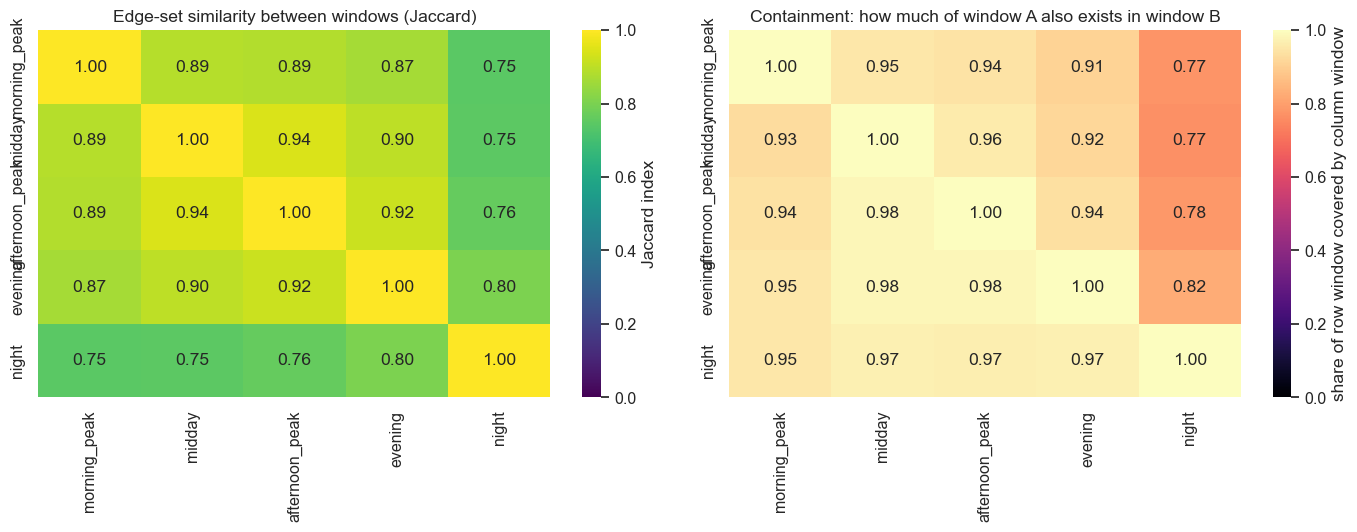

window_b,morning_peak,midday,afternoon_peak,evening,night
window_a,,,,,
morning_peak,1.0000,0.8871,0.8867,0.8667,0.7458
midday,0.8871,1.0000,0.9429,0.9001,0.7499
afternoon_peak,0.8867,0.9429,1.0000,0.9205,0.7645
evening,0.8667,0.9001,0.9205,1.0000,0.8043
night,0.7458,0.7499,0.7645,0.8043,1.0000


In [14]:
# --- Pairwise edge-set overlap between windows ----------------------------
undirected_sets = {
    name: {tuple(sorted((u, v))) for (u, v) in edge_sets['all'][w].keys()}
    for w, (name, _, _) in enumerate(WINDOWS)
}

overlap_rows = []
for a in WINDOW_NAMES:
    for b in WINDOW_NAMES:
        A, B = undirected_sets[a], undirected_sets[b]
        inter = len(A & B)
        union = len(A | B)
        overlap_rows.append({
            'window_a': a,
            'window_b': b,
            'edges_a': len(A),
            'edges_b': len(B),
            'shared_edges': inter,
            'jaccard': round(inter / union, 4) if union else 0.0,
            'share_of_a_covered_by_b': round(inter / len(A), 4) if A else 0.0,
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(TABLES / 'window_edge_overlap.csv', index=False, encoding='utf-8-sig')

jac = overlap_df.pivot(index='window_a', columns='window_b', values='jaccard').reindex(
    index=WINDOW_NAMES, columns=WINDOW_NAMES)
cov = overlap_df.pivot(index='window_a', columns='window_b',
                       values='share_of_a_covered_by_b').reindex(
    index=WINDOW_NAMES, columns=WINDOW_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(jac, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=axes[0],
            cbar_kws={'label': 'Jaccard index'})
axes[0].set_title('Edge-set similarity between windows (Jaccard)')
sns.heatmap(cov, annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1, ax=axes[1],
            cbar_kws={'label': 'share of row window covered by column window'})
axes[1].set_title('Containment: how much of window A also exists in window B')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES / 'window_edge_overlap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

jac

## 15. The busiest segments in the morning peak and the night window

We finish the graph checks by listing the busiest segments in the morning peak and at night. The names make the aggregate results easier to inspect: we can see whether peak service is concentrated on urban corridors and whether the night list is much narrower. This is a sanity check on the window assignment, not a separate statistical test.

In [15]:
# --- Top segments per window (sanity check) -------------------------------
def top_segments(window_name, k=TOP_N):
    w = WINDOW_INDEX[window_name]
    rows = []
    for (u, v), c in edge_sets['all'][w].items():
        rows.append({
            'from_stop': u,
            'from_name': NODE_ATTR.get(u, _DEFAULT_ATTR)['stop_name'],
            'to_stop': v,
            'to_name': NODE_ATTR.get(v, _DEFAULT_ATTR)['stop_name'],
            'trip_frequency': c,
        })
    return (pd.DataFrame(rows)
            .sort_values('trip_frequency', ascending=False)
            .head(k)
            .reset_index(drop=True))


print('=== Busiest segments, morning_peak ===')
display(top_segments('morning_peak'))
print('=== Busiest segments, night ===')
display(top_segments('night'))

=== Busiest segments, morning_peak ===


,from_stop,from_name,to_stop,to_name,trip_frequency
0,13358,סמינר הקיבוצים/דרך נמיר,12910,דרך נמיר/יהודה המכבי,1224
1,29483,המסגר/המלאכה,48363,ת.רק''ל יהודית/דרך מנחם בגין,1057
2,51284,דרך נמיר/שדרות שאול המלך,13103,קניון עזריאלי/דרך מנחם בגין,1010
3,8756,מרכז שטנר/כנפי נשרים,8757,בית ענבר/כנפי נשרים,974
4,13103,קניון עזריאלי/דרך מנחם בגין,13206,קריית הממשלה/דרך מנחם בגין,949
5,14077,מחלף גהה/דרך ז'בוטינסקי,14347,ת.רק''ל אהרונוביץ'/דרך ז'בוטינסקי,921
6,13227,ז'בוטינסקי/ אבו חצירא,13032,דרך ז'בוטינסקי/דב גרונר,903
7,13181,דרך נמיר/פנקס,13067,דרך נמיר/יהודה המכבי,902
8,22099,ת. רק''ל בלינסון/קניון אבנת,16212,ת.רק''ל שחם/דרך ז'בוטינסקי,880
9,8757,בית ענבר/כנפי נשרים,49466,מסוף הר נוף/כנפי נשרים,878


=== Busiest segments, night ===


,from_stop,from_name,to_stop,to_name,trip_frequency
0,13341,הרב כהנמן/קוקה קולה,13037,כהנמן/הרב זוננפלד,771
1,29432,רבי עקיבא/גן ורשה,13174,רבי עקיבא/הרב קוק,628
2,47411,אוהל יהושע/זית רענן,10742,שמגר/אוהל יהושע,627
3,49737,שדרות גולדה מאיר/הרטום,8636,גולדה/שלמה הלוי,619
4,29342,מחלף גבעת שמואל/מבצע קדש,13341,הרב כהנמן/קוקה קולה,595
5,11292,שפע חיים/דורש טוב,47411,אוהל יהושע/זית רענן,592
6,8756,מרכז שטנר/כנפי נשרים,8757,בית ענבר/כנפי נשרים,590
7,13174,רבי עקיבא/הרב קוק,13043,רבי עקיבא/הראשונים,587
8,47982,גולדה מאיר/שלמה הלוי,37251,קרית מדע/גולדה מאיר,571
9,13227,ז'בוטינסקי/ אבו חצירא,13032,דרך ז'בוטינסקי/דב גרונר,570


## 16. Writing the stage summary

We collect the settings and main results in `window_construction_summary.json`: the window definitions, streaming counts, run time, after-midnight rows, per-window statistics, trip counts by day type, and data limitations. The final file listing lets us check that every expected table, figure, and graph was actually written.

In [16]:
# --- Stage summary --------------------------------------------------------
summary = {
    'stage': '19_time_of_day_graphs',
    'source': 'GTFS stop_times.txt + trips.txt + calendar.txt (SCHEDULED service, not ridership)',
    'windows': [{'window': n, 'start_hour': s, 'end_hour': e,
                 'hours': window_hours(s, e)} for n, s, e in WINDOWS],
    'segment_assignment_rule': 'departure time at the ORIGIN stop of the segment, hour taken modulo 24',
    'streaming_pass': stream_stats,
    'calendar': {
        'services_total': int(n_services),
        'services_with_no_day_flag': int(n_unknown_services),
        'trips_total': int(n_trips_total),
        'trips_by_day_type_overlapping': {k: int(v) for k, v in trip_day_counts.items()},
        'calendar_dates_txt_present': (DATA / 'calendar_dates.txt').exists(),
    },
    'per_window': {
        r['window']: {k: (float(r[k]) if k in ('avg_degree', 'largest_component_share')
                          else int(r[k]))
                      for k in ('trips', 'nodes', 'directed_edges',
                                'avg_degree', 'largest_component_share')}
        for r in summary_rows
    },
    'caveats': [
        'All counts are SCHEDULED trips from the GTFS timetable. They are not observed '
        'ridership, boardings, or vehicle occupancy; nothing in this feed measures demand.',
        'A trip that crosses a window boundary is counted in every window it touches, so the '
        'trips column sums to more than the number of distinct trips.',
        'Day types (weekday / friday / saturday) are not mutually exclusive: a service running '
        'Sunday-Friday is counted under both weekday and friday.',
        'Services with all seven day flags set to 0 have an unknown day of week because this '
        'feed ships no calendar_dates.txt; they are excluded from the day-type tables but '
        'included in the all-service window graphs.',
        'GTFS hours >= 24 are folded modulo 24, so a 25:30 departure is treated as 01:30 for '
        'the purpose of window assignment.',
    ],
}

with open(STAGE / 'window_construction_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Files written under ' + str(STAGE) + ':')
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print('  ' + str(p.relative_to(STAGE)).ljust(46) +
              format(p.stat().st_size / 1024, '>10,.0f') + ' KB')

Files written under C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\19_time_of_day_graphs:
  figures\connectivity_by_window.png                    74 KB
  figures\network_size_by_window.png                    80 KB
  figures\service_volume_by_hour.png                   272 KB
  figures\weekday_vs_weekend_by_window.png              80 KB
  figures\window_edge_overlap.png                      147 KB
  graph_afternoon_peak.pkl                           3,534 KB
  graph_evening.pkl                                  3,420 KB
  graph_midday.pkl                                   3,577 KB
  graph_morning_peak.pkl                             3,528 KB
  graph_night.pkl                                    2,993 KB
  tables\edges_afternoon_peak.csv                      712 KB
  tables\edges_evening.csv                             676 KB
  tables\edges_midday.csv                              737 KB
  tables\edges_morning_peak.csv                        705 KB
  tables\e

## Conclusions

We now have a separate scheduled graph for each part of the day instead of treating the full feed as if every service runs at once. The numbers make the change fairly clear:

1. **Daytime coverage is broad, but it thins after the evening.** The morning, midday, and afternoon graphs each contain about 30,000 active stations and 47,000-48,000 directed segments. The evening drops to 29,359 stations and 44,936 segments, while the night graph drops to 25,967 stations and 38,203 segments. Average degree also falls from 3.180 at midday to 2.932 at night.

2. **Most active stations still belong to one main component.** The largest-component share stays near 99.25%-99.27% through the evening and falls to 98.83% at night. That is a small percentage change, but it occurs alongside the much larger loss of active stations and segments.

3. **The night graph is not identical to any daytime graph.** Its edge Jaccard similarity is 0.746 with the morning graph, 0.750 with midday, 0.765 with afternoon, and 0.804 with evening. We keep the containment values beside Jaccard because they tell us how much of one window survives in the other, not just how similar the two sets are overall.

4. **Day type changes the available supply even more.** Summed across the five windows, Saturday segment-frequency coverage is 38.0% of the weekday value. We treat that as scheduled supply coverage, not passenger access or demand.

5. **The construction still has two timing limits.** We assign a segment to the departure window of its origin stop, so a trip crossing a boundary is split according to each segment's own origin time. Services with zero calendar flags remain `unknown` because we do not have `calendar_dates.txt` here.

Our conclusion is that the full-day union is useful for showing where service can exist, but it overstates what is simultaneously available, especially at night and on Saturday. We save `graph_<window>.pkl`, `tables/edges_<window>.csv`, and `tables/window_summary.csv` so notebook 20 can test how those supply changes affect station rankings and removal damage.